In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [ ]:
# DAY 1 & 2---

In [4]:
# Load Datasets/---
sales_df = pd.read_csv('sales.csv')

In [5]:
churn_df = pd.read_csv('customer_churn.csv')

In [6]:
# check for missing data/--
print("sales Missing : \n", sales_df.isnull().sum())

sales Missing : 
 Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [7]:
print("churn Missing : \n",churn_df.isnull().sum())

churn Missing : 
 CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [8]:
# Data cleaning/--
sales_df['CustomerID'] = 'C' + sales_df['Customer_ID'].str.extract(r'(\d+)')[0].str.zfill(5)

In [10]:
# convert dates nd create calculated columns/--
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df['Month'] = sales_df['Date'].dt.strftime('%B')

In [11]:
# merge datasets/--
merged_df = pd.merge(sales_df, churn_df, on='CustomerID', how='inner')
print(f"\nData merged successfully! Rows: {merged_df.shape[0]}")


Data merged successfully! Rows: 100


In [12]:
# DAY 3 AND 4 -- AGGREGATIONS AND CUSTOMER/SALES ANALYSIS

In [13]:
# Aggregation 1: Identify Top Customers by Revenue (Customer Analysis)
top_customers = sales_df.groupby('Customer_ID')['Total_Sales'].sum().sort_values(ascending=False).head(5)
print("\n--- Top 5 Valuable Customers ---")
print(top_customers)

# Aggregation 2: Regional Revenue Distribution
regional_sales = sales_df.groupby('Region')['Total_Sales'].sum().sort_values(ascending=False)
print("\n--- Sales by Region ---")
print(regional_sales)

# Aggregation 3: Monthly Sales Trend (Sales Pattern Analysis)
monthly_trends = sales_df.groupby('Month')['Total_Sales'].sum().reindex(['January', 'February', 'March', 'April'])
print("\n--- Monthly Revenue Trends ---")
print(monthly_trends)


--- Top 5 Valuable Customers ---
Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
Name: Total_Sales, dtype: int64

--- Sales by Region ---
Region
North    3983635
South    3737852
East     2519639
West     2123922
Name: Total_Sales, dtype: int64

--- Monthly Revenue Trends ---
Month
January     4120524
February    2656050
March       4485006
April       1103468
Name: Total_Sales, dtype: int64


In [14]:
# DAY 5 -- ADVANCED ANALYSIS (PIVOT TABLES AND RETENTION)/--


In [15]:
# Create a Pivot Table analyzing Churn Rates across Contract type and Payment Methods

churn_pivot = churn_df.pivot_table(index='Contract', columns='PaymentMethod', values='Churn', aggfunc='mean')
print("\n--- Churn Rate Pivot Table (Contract vs Payment Method) ---")
print(churn_pivot)


--- Churn Rate Pivot Table (Contract vs Payment Method) ---
PaymentMethod   Bank Transfer  Credit Card  Electronic Check
Contract                                                    
Month-to-month       0.156863     0.246154          0.203704
One year             0.015385     0.050847          0.064516
Two year             0.046512     0.092593          0.063830


In [16]:
# Calculate Average Metrics for Churned vs Retained Customers

retention_stats = churn_df.groupby('Churn')[['Tenure', 'MonthlyCharges']].mean()
print("\n--- Retention Risk Statistics ---")
print(retention_stats)


--- Retention Risk Statistics ---
          Tenure  MonthlyCharges
Churn                           
0      40.152125      111.722595
1       6.000000      129.773585


In [17]:
# DAY 6 /-- DASHBOARD ND VISULAIZATIONS/--

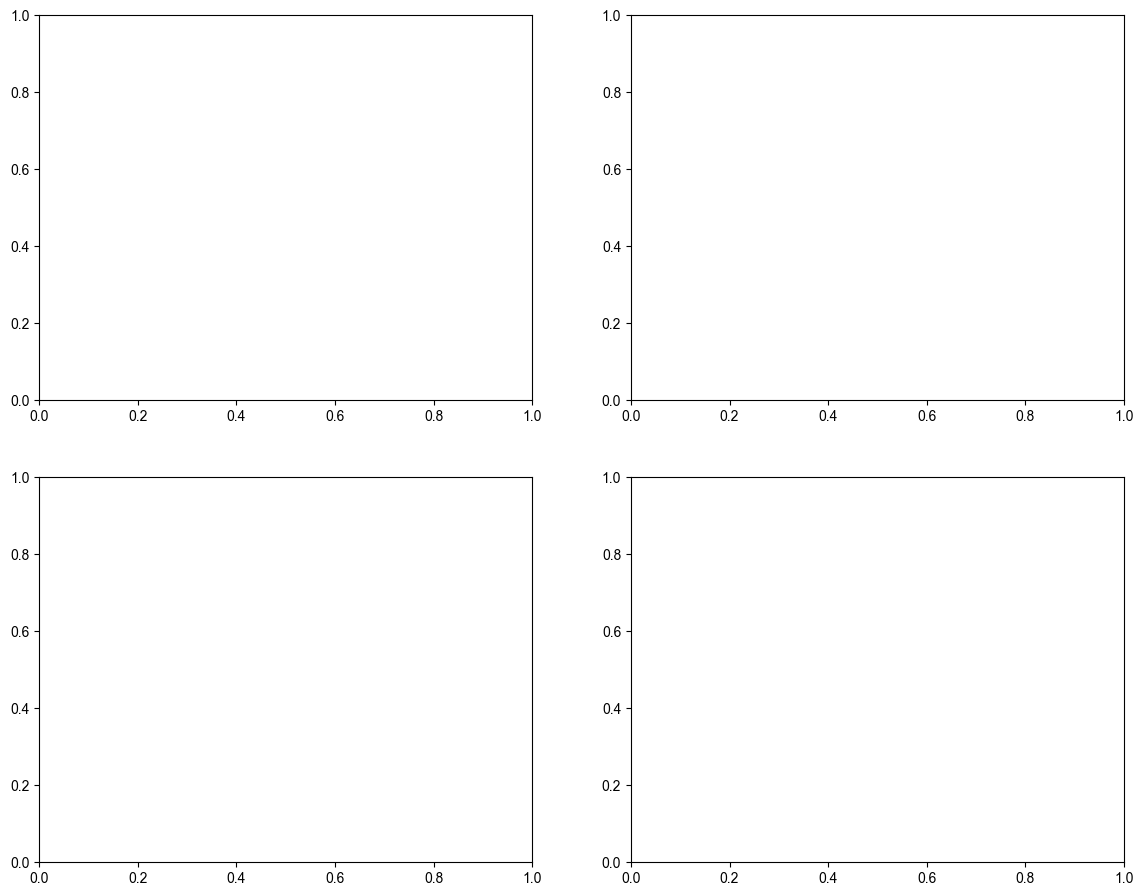

In [ ]:
# Set up a professional 4-panel dashboard canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
sns.set_theme(style="whitegrid")
plt.savefig('sales_perfrormance_dashboard.png')

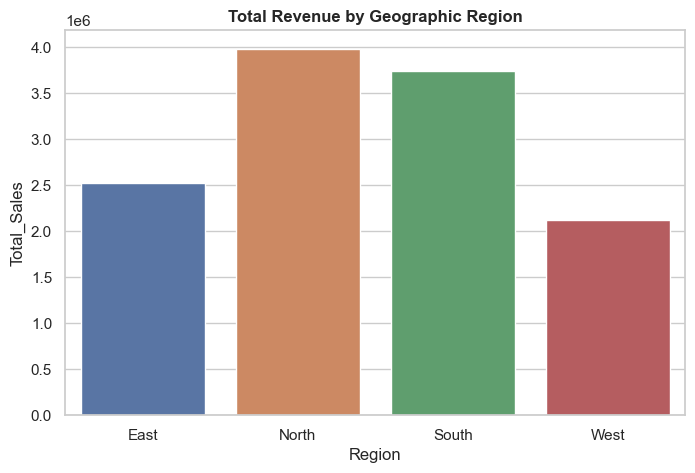

In [25]:
# 1. Create a figure and a single axis
fig, ax = plt.subplots(figsize=(8, 5))

# 2. Group your data
regional_sales = sales_df.groupby('Region')['Total_Sales'].sum().reset_index()

# 3. Plot the bar chart (passing 'ax' instead of 'axes[0,0]')
sns.barplot(
    ax=ax, 
    data=regional_sales, 
    x='Region', 
    y='Total_Sales', 
    hue='Region', 
    legend=False
)

# 4. Set the title
ax.set_title('Total Revenue by Geographic Region', fontsize=12, weight='bold')

# 5. Force the plot to render and show on screen
plt.show()

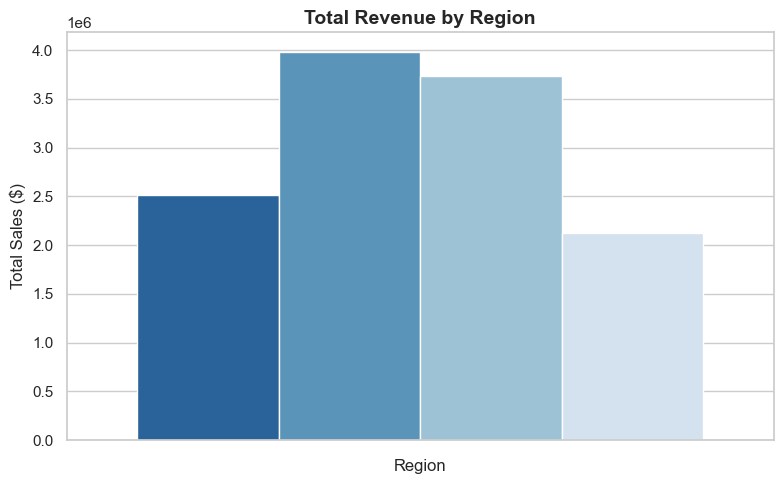

In [29]:
# Group data by Region
region_sales = sales_df.groupby('Region')['Total_Sales'].sum().reset_index()

# Plot Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=region_sales, hue='Region', y='Total_Sales', palette='Blues_r',legend = False)

# Add Labels
plt.title('Total Revenue by Region', fontsize=14, weight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Show Chart
plt.tight_layout()
plt.show()

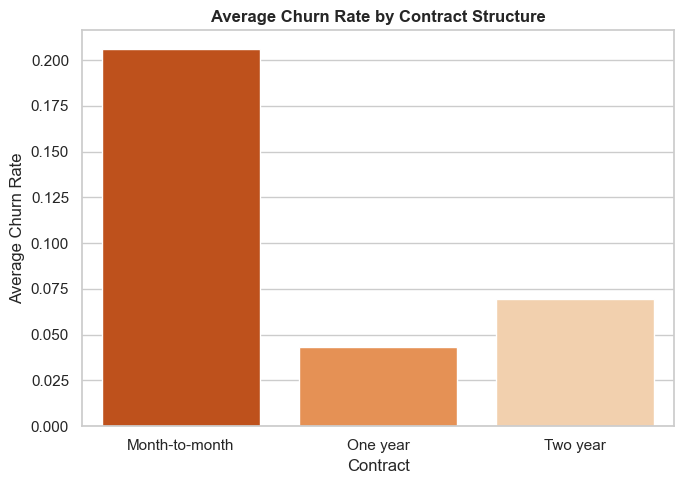

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
sns.set_theme(style="whitegrid")


sns.barplot(
    ax=axes, 
    data=churn_df.groupby('Contract')['Churn'].mean().reset_index(), 
    x='Contract', 
    y='Churn', 
    hue='Contract',     
    palette='Oranges_r'
)

# Title set 
axes.set_title('Average Churn Rate by Contract Structure', fontsize=12, weight='bold')
axes.set_ylabel('Average Churn Rate')


if axes.get_legend():
    axes.get_legend().remove()

# 4. CHART SHOW  COMMAND
plt.tight_layout()
plt.show()

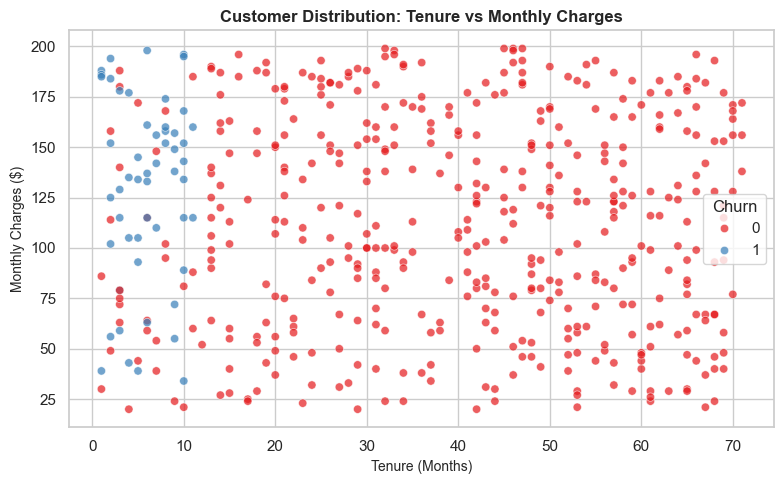

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset ko load karein
churn_df = pd.read_csv('customer_churn.csv')

# 2. Matplotlib figure aur axes fresh banayein
fig, ax = plt.subplots(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# 3. Scatter Plot banayein (Har parameter line separated)
sns.scatterplot(
    ax=ax, 
    data=churn_df, 
    x='Tenure', 
    y='MonthlyCharges', 
    hue='Churn', 
    alpha=0.7, 
    palette='Set1'
)

# 4. Labels aur Title add karein (Line break ke bina)
ax.set_title('Customer Distribution: Tenure vs Monthly Charges', fontsize=12, weight='bold')
ax.set_xlabel('Tenure (Months)', fontsize=10)
ax.set_ylabel('Monthly Charges ($)', fontsize=10)

# 5. Purane plots ko clear karke sirf ye naya graph display karein
plt.tight_layout()
plt.show()